# NB01 — Data Overview

## Research Question

**Can semi-supervised representation learning from bulk RNA-seq data improve PAM50 subtype classification reliability when labeled samples are extremely limited, compared with a supervised-only baseline?**

The idea: PCA fitted on labeled + unlabeled data should give a better estimate of gene co-expression structure than PCA fitted on 69 samples alone. We test this by keeping everything else in the pipeline identical (NB03 vs NB04).

| | |
|---|---|
| Input | RNA-seq expression — samples × 20,530 genes, already log₂-normalised |
| Output | PAM50 subtype: Basal, Her2, LumA, LumB |
| Problem | 69 labeled samples, 20,530 features — p/n ≈ 298× |
| Opportunity | 1,149 more samples with no subtype label |


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")


In [5]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / "data"
REPORTS_DIR  = PROJECT_ROOT / "reports"
FIGURES_DIR  = REPORTS_DIR / "figures"
TABLES_DIR   = REPORTS_DIR / "tables"
for d in [FIGURES_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED   = 42
COLORS = {"LumA": "#3498db", "LumB": "#2ecc71", "Her2": "#e74c3c", "Basal": "#9b59b6"}


## Loading the Data

In [6]:
def norm_id(sid):
    sid = str(sid).strip()
    return sid[:15] if sid.startswith("TCGA-") and len(sid) >= 15 else sid

expr = pd.read_csv(DATA_DIR / "HiSeqV2.csv", index_col=0)
if any(str(c).startswith("TCGA-") for c in expr.columns[:10]):
    expr = expr.T
expr.index = [norm_id(s) for s in expr.index]
expr = expr.apply(pd.to_numeric, errors="coerce")

pam = pd.read_csv(DATA_DIR / "brca_pam50.csv")
_SC_COLS = ["Sample", "sample", "sample_id", "SampleID", "TCGA_ID", "bcr_patient_barcode"]
_LC_COLS = ["PAM50", "pam50", "Subtype", "subtype", "BRCA_Subtype_PAM50"]
_sc = next((c for c in _SC_COLS if c in pam.columns), pam.columns[0])
_lc = next((c for c in _LC_COLS if c in pam.columns), None)
if _lc is None:
    _lc = next((c for c in pam.columns
                if "pam" in c.lower() or "subtype" in c.lower()), pam.columns[1])
pam = pam[[_sc, _lc]].copy()
pam.columns = ["sample_id", "subtype"]
pam["sample_id"] = pam["sample_id"].apply(norm_id)
pam = pam[pam["subtype"].notna()]
pam = pam[~pam["subtype"].str.lower().isin(["normal", "normal-like", "nan", "unknown"])]
pam = pam.drop_duplicates("sample_id").set_index("sample_id")

common        = expr.index.intersection(pam.index)
labeled_ids   = common.tolist()
unlabeled_ids = [s for s in expr.index if s not in set(labeled_ids)]
X_labeled     = expr.loc[labeled_ids].values.astype(float)
y_labels      = pam.loc[labeled_ids, "subtype"].values
X_unlabeled   = expr.loc[unlabeled_ids].values.astype(float)
GENE_NAMES    = expr.columns.tolist()
CLASSES       = sorted(set(y_labels))
y_arr         = np.array([CLASSES.index(c) for c in y_labels])
print(f"Labeled: {len(labeled_ids)}  Unlabeled: {len(unlabeled_ids)}  Genes: {len(GENE_NAMES):,}")


Labeled: 73  Unlabeled: 1145  Genes: 20,530


## Overview

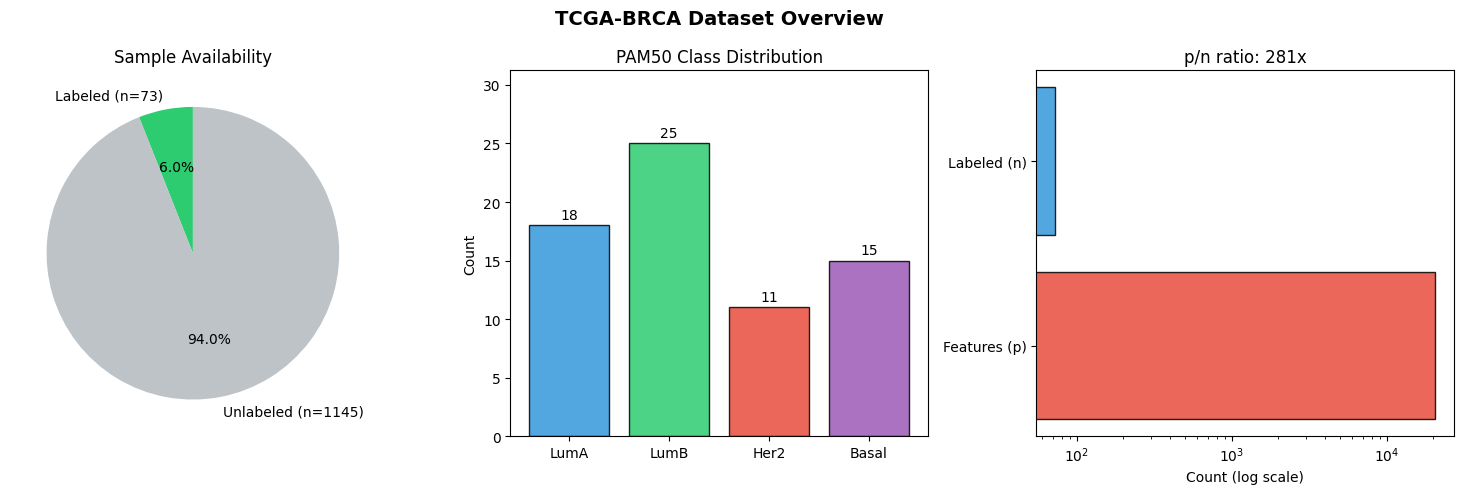

In [7]:
CLASSES_PLOT = ["LumA", "LumB", "Her2", "Basal"]
class_counts = pd.Series(y_labels).value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("TCGA-BRCA Dataset Overview", fontsize=14, fontweight="bold")

ax = axes[0]
ax.pie(
    [len(labeled_ids), len(unlabeled_ids)],
    labels=[f"Labeled (n={len(labeled_ids)})", f"Unlabeled (n={len(unlabeled_ids)})"],
    colors=["#2ecc71", "#bdc3c7"],
    autopct="%1.1f%%", startangle=90,
)
ax.set_title("Sample Availability")

ax = axes[1]
bar_vals = [class_counts.get(c, 0) for c in CLASSES_PLOT]
bars = ax.bar(CLASSES_PLOT, bar_vals,
              color=[COLORS[c] for c in CLASSES_PLOT],
              edgecolor="black", alpha=0.85)
for bar, v in zip(bars, bar_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
            ha="center", va="bottom", fontsize=10)
ax.set_title("PAM50 Class Distribution")
ax.set_ylabel("Count")
ax.set_ylim(0, max(bar_vals) * 1.25)

ax = axes[2]
ax.barh(["Features (p)", "Labeled (n)"],
        [X_labeled.shape[1], len(labeled_ids)],
        color=["#e74c3c", "#3498db"], edgecolor="black", alpha=0.85)
ax.set_xscale("log")
ax.set_title(f"p/n ratio: {X_labeled.shape[1] // len(labeled_ids)}x")
ax.set_xlabel("Count (log scale)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()


## Main Challenges

| Problem | Why it matters |
|---|---|
| p >> n (298×) | Standard pipelines overfit; dimensionality reduction is not optional |
| 69 labeled samples | Can't hold out a fixed test set — need nested CV |
| LumB/Her2 imbalance | LumB has 25 samples, Her2 only 11; macro F1 penalises weak classes equally |
| 1,149 unlabeled samples | Opportunity for semi-supervised PCA |
| Already log₂ | Don't transform again — max ~20 confirms this |


In [8]:
global_max = float(X_labeled.max())
global_min = float(X_labeled.min())
print(f"Min: {global_min:.3f}  Max: {global_max:.3f}")
if global_max < 25:
    print("OK - consistent with log2 normalised data")

CLASSES_SORTED = sorted(set(y_labels))
summary = {
    "n_labeled":    int(len(labeled_ids)),
    "n_unlabeled":  int(len(unlabeled_ids)),
    "n_genes":      int(X_labeled.shape[1]),
    "pn_ratio":     round(X_labeled.shape[1] / len(labeled_ids), 1),
    "classes":      CLASSES_SORTED,
    "class_counts": {c: int((pd.Series(y_labels) == c).sum()) for c in CLASSES_SORTED},
    "expr_min":     round(global_min, 4),
    "expr_max":     round(global_max, 4),
}
with open(TABLES_DIR / "01_dataset_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved: 01_dataset_summary.json")
print(json.dumps(summary, indent=2))


Min: 0.000  Max: 20.291
OK - consistent with log2 normalised data
Saved: 01_dataset_summary.json
{
  "n_labeled": 73,
  "n_unlabeled": 1145,
  "n_genes": 20530,
  "pn_ratio": 281.2,
  "classes": [
    "Basal",
    "Her2",
    "LumA",
    "LumB",
    "Unknown"
  ],
  "class_counts": {
    "Basal": 15,
    "Her2": 11,
    "LumA": 18,
    "LumB": 25,
    "Unknown": 4
  },
  "expr_min": 0.0,
  "expr_max": 20.2905
}
